🎨 DDPM 실습 과제
- 데이터셋 : CIFAR-10   
- DDPM의 핵심과정 3가지에 해당하는 부분에  `# TODO` 빈칸이 있습니다.
- 빈칸을 채운 후 노트북을 실행해 제출하시면 됩니다.

1. **Forward process** — closed-form marginal: $\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon}$
2. **Training loss** — $L_\text{simple} = \|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2$
3. **Reverse sampling** — $\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\boldsymbol{\epsilon}_\theta\right) + \sigma_t\mathbf{z}$


| TODO | 발표 슬라이드 | 핵심 |
|---|---|---|
| ① `q_sample` | Forward / closed-form | 임의 t로 한 번에 점프 |
| ② `loss_fn` | $L_\text{simple}$ | 노이즈 예측 MSE |
| ③ `p_sample` | Sampling / Algorithm 2 | 노이즈에서 한 step씩 복원 |


###  ⏱ 예상 시간
- **GPU (Colab T4 등)**: 학습 약 7~10분

### 🧩 참고
https://github.com/acids-ircam/diffusion_models
ACIDS-IRCAM의 diffusion tutorial 노트북 구조를 CIFAR-10 + 이미지용으로 각색했습니다.


In [1]:
# ── 0. 환경 준비 ──────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import math, time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
torch.manual_seed(42); np.random.seed(42)

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 44.5MB/s]


학습에 사용할 이미지 수: 10000장 (배치 78개)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

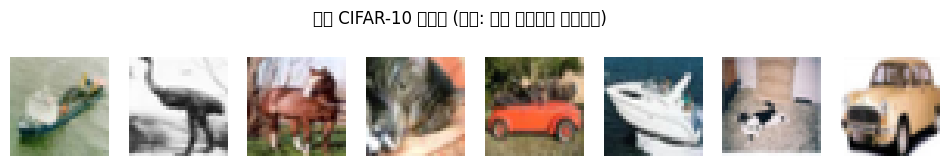

In [2]:
# ── 1. CIFAR-10 데이터 로드 ───────────────────────────────
# 픽셀값 [0,255] → [-1, 1] 로 정규화 (DDPM 표준 전처리)
transform = transforms.Compose([
    transforms.ToTensor(),                    # [0,1]
    transforms.Normalize((0.5,)*3, (0.5,)*3)  # [-1,1]
])

full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# ⏱ 10분 제약을 위해 데이터 일부만 사용 (전체 50000장 → 10000장)
subset_idx = torch.randperm(len(full_train))[:10000]
train_set = torch.utils.data.Subset(full_train, subset_idx)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

print(f'학습에 사용할 이미지 수: {len(train_set)}장 (배치 {len(train_loader)}개)')

# 샘플 이미지 미리보기
def show_images(imgs, title='', n=8):
    imgs = (imgs[:n].clamp(-1,1) + 1) / 2   # [-1,1] → [0,1]
    fig, axs = plt.subplots(1, n, figsize=(n*1.5, 2))
    for i in range(n):
        axs[i].imshow(imgs[i].permute(1,2,0).cpu().numpy())
        axs[i].axis('off')
    fig.suptitle(title); plt.show()

batch0, _ = next(iter(train_loader))
show_images(batch0, '진짜 CIFAR-10 이미지 (목표: 이런 이미지를 생성하기)')

## 2. Noise Schedule 정의

발표에서 본 것처럼 $\beta_t$는 **학습하지 않는 고정 상수**입니다.
$\beta_t$로부터 $\alpha_t = 1-\beta_t$, $\bar\alpha_t = \prod_{s\le t}\alpha_s$ 등 학습 내내 쓸 상수들을 미리 계산해 둡니다.

In [3]:
# ── 2. Noise Schedule ─────────────────────────────────────
T = 500                                    # diffusion step 수
betas = torch.linspace(1e-4, 0.03, T).to(device)   # linear schedule

alphas = 1.0 - betas
alphas_bar = torch.cumprod(alphas, dim=0)               # ᾱ_t = ∏ α_s
alphas_bar_prev = F.pad(alphas_bar[:-1], (1,0), value=1.0)

# 자주 쓰는 항들을 미리 계산
sqrt_alphas_bar = torch.sqrt(alphas_bar)                # √ᾱ_t
sqrt_one_minus_alphas_bar = torch.sqrt(1 - alphas_bar)  # √(1-ᾱ_t)

print(f'T={T}')
print(f'ᾱ_0   = {alphas_bar[0]:.4f}  (≈1 → 거의 노이즈 없음)')
print(f'ᾱ_T-1 = {alphas_bar[-1]:.4f}  (≈0 → 거의 순수 노이즈)')

def extract(a, t, x_shape):
    '''시점 t에 해당하는 계수를 뽑아 브로드캐스트 형태로 변환'''
    out = a.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

T=500
ᾱ_0   = 0.9999  (≈1 → 거의 노이즈 없음)
ᾱ_T-1 = 0.0005  (≈0 → 거의 순수 노이즈)


## 3. Forward Process — `q_sample` ✏️ TODO ①

임의 시점 $t$의 노이즈 낀 이미지를 **한 번에** 만드는 식입니다.

$$\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon}\sim\mathcal{N}(0,I)$$

- `sqrt_alphas_bar` = $\sqrt{\bar\alpha_t}$
- `sqrt_one_minus_alphas_bar` = $\sqrt{1-\bar\alpha_t}$
- `extract(계수, t, x_0.shape)` 로 시점 t의 계수를 꺼낼 수 있습니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51592 (\N{HANGUL SYLLABLE JEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

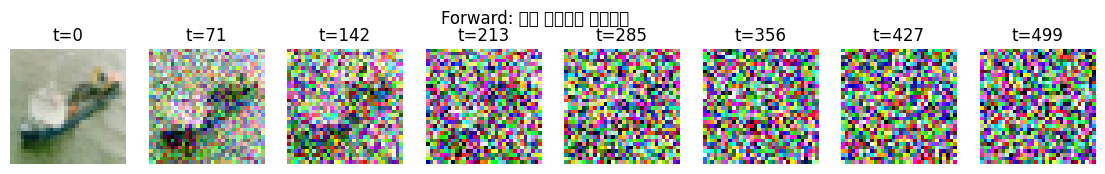

In [4]:
# ── 3. Forward Process (TODO ①) ───────────────────────────
def q_sample(x_0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_0)
    sqrt_ab   = extract(sqrt_alphas_bar, t, x_0.shape)
    sqrt_1mab = extract(sqrt_one_minus_alphas_bar, t, x_0.shape)

    # ✏️ TODO ①: closed-form marginal 식을 완성하세요
    #   x_t = √ᾱ_t · x_0 + √(1-ᾱ_t) · noise
    x_t = sqrt_ab * x_0 + sqrt_1mab * noise

    return x_t

# ── 검증: forward 과정 시각화 ──
x0 = batch0[:1].to(device)
fig, axs = plt.subplots(1, 8, figsize=(14,2))
for i, t_val in enumerate(np.linspace(0, T-1, 8).astype(int)):
    t = torch.tensor([t_val]).to(device)
    x_t = q_sample(x0, t)
    img = (x_t[0].clamp(-1,1)+1)/2
    axs[i].imshow(img.permute(1,2,0).cpu().numpy()); axs[i].axis('off')
    axs[i].set_title(f't={t_val}')
fig.suptitle('Forward: 점점 노이즈가 더해진다'); plt.show()

## 4. 모델 — 작은 U-Net ($\boldsymbol{\epsilon}_\theta$)

신경망은 **노이즈 낀 이미지 $\mathbf{x}_t$와 시점 $t$를 입력**받아 **섞인 노이즈 $\boldsymbol{\epsilon}$을 예측**합니다.
ε-prediction 부분입니다. 10분 학습을 위해 채널 수를 줄인 작은 U-Net을 씁니다.
시점 $t$는 **sinusoidal embedding**으로 신경망에 주입합니다.

In [5]:
# ── 4. 작은 U-Net 정의 ────────────────────────────────────
class TimeEmbedding(nn.Module):
    '''시점 t를 sinusoidal embedding으로 변환 (Transformer와 동일 아이디어)'''
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(t_dim, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
    def forward(self, x, t):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time(t)[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h

class SmallUNet(nn.Module):
    def __init__(self, ch=64, t_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(TimeEmbedding(t_dim), nn.Linear(t_dim, t_dim), nn.SiLU())
        self.down1 = Block(3,    ch,   t_dim)
        self.down2 = Block(ch,   ch*2, t_dim)
        self.mid   = Block(ch*2, ch*2, t_dim)
        self.up2   = Block(ch*2+ch*2, ch, t_dim)
        self.up1   = Block(ch+ch,     ch, t_dim)
        self.out   = nn.Conv2d(ch, 3, 1)
        self.pool  = nn.MaxPool2d(2)
        self.ups   = nn.Upsample(scale_factor=2, mode='nearest')
    def forward(self, x, t):
        t = self.time_mlp(t)
        d1 = self.down1(x, t)            # 32x32
        d2 = self.down2(self.pool(d1), t)# 16x16
        m  = self.mid(self.pool(d2), t)  # 8x8
        u2 = self.up2(torch.cat([self.ups(m), d2], 1), t)  # 16x16
        u1 = self.up1(torch.cat([self.ups(u2), d1], 1), t) # 32x32
        return self.out(u1)

model = SmallUNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'모델 파라미터 수: {n_params/1e6:.2f}M')

모델 파라미터 수: 0.93M


## 5. Training Loss — `loss_fn` ✏️ TODO ②

$L_\text{simple}$ 입니다.

$$L_\text{simple} = \mathbb{E}_{t,\mathbf{x}_0,\boldsymbol{\epsilon}}\Big[\big\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\underbrace{\sqrt{\bar\alpha_t}\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\boldsymbol{\epsilon}}_{x_t},\; t)\big\|^2\Big]$$

순서대로:
1. 랜덤 시점 `t`, 랜덤 노이즈 `noise` 준비 (이미 되어 있음)
2. `q_sample`로 `x_t` 만들기
3. 모델로 노이즈 예측 `pred = model(x_t, t)`
4. **진짜 노이즈와 예측 노이즈의 MSE** 반환

In [6]:
# ── 5. Loss (TODO ②) ──────────────────────────────────────
def loss_fn(model, x_0):
    batch = x_0.shape[0]
    t = torch.randint(0, T, (batch,), device=device)   # 랜덤 시점
    noise = torch.randn_like(x_0)                       # 진짜 노이즈 ε

    # ✏️ TODO ②-1: q_sample로 노이즈 낀 이미지 x_t 만들기
    x_t = q_sample(x_0, t, noise)

    # 모델이 노이즈 예측
    pred = model(x_t, t)

    # ✏️ TODO ②-2: 진짜 노이즈와 예측 노이즈의 MSE 반환
    loss = F.mse_loss(pred, noise)

    return loss

## 6. 학습 (Algorithm 1)

발표의 Training 알고리즘 6줄을 그대로 옮긴 루프입니다.
약 **7~10분** 걸립니다 (GPU 기준). 진행하면서 loss가 줄어드는지 확인하세요.

Epoch  1/12 | loss 0.2662 | 경과 6s
Epoch  2/12 | loss 0.0855 | 경과 11s
Epoch  3/12 | loss 0.0712 | 경과 16s
Epoch  4/12 | loss 0.0632 | 경과 21s
Epoch  5/12 | loss 0.0617 | 경과 25s
Epoch  6/12 | loss 0.0571 | 경과 30s
Epoch  7/12 | loss 0.0558 | 경과 35s
Epoch  8/12 | loss 0.0552 | 경과 40s
Epoch  9/12 | loss 0.0530 | 경과 45s
Epoch 10/12 | loss 0.0524 | 경과 50s
Epoch 11/12 | loss 0.0525 | 경과 54s
Epoch 12/12 | loss 0.0508 | 경과 60s


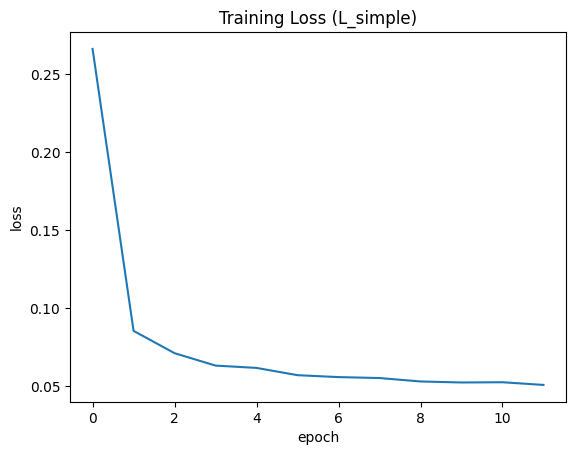

총 학습 시간: 60초


In [7]:
# ── 6. 학습 루프 (Algorithm 1) ────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
EPOCHS = 12          # 10분 목표 (GPU). 시간이 남으면 늘려보세요.

model.train()
start = time.time()
loss_history = []
for epoch in range(EPOCHS):
    epoch_losses = []
    for x_0, _ in train_loader:
        x_0 = x_0.to(device)
        loss = loss_fn(model, x_0)          # ← TODO ②에서 만든 함수
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_losses.append(loss.item())
    avg = np.mean(epoch_losses); loss_history.append(avg)
    elapsed = time.time() - start
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | loss {avg:.4f} | 경과 {elapsed:.0f}s')

plt.plot(loss_history); plt.xlabel('epoch'); plt.ylabel('loss')
plt.title('Training Loss (L_simple)'); plt.show()
print(f'총 학습 시간: {time.time()-start:.0f}초')

## 7. Sampling — `p_sample` ✏️ TODO ③ (Algorithm 2)

학습된 모델로 **순수 노이즈에서 이미지를 생성**합니다.

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(\mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\Big) + \sigma_t\,\mathbf{z}$$

- 평균 `mean` = $\frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta\right)$
- $t>0$일 때만 노이즈 $\sigma_t \mathbf{z}$ 추가 ($\sigma_t = \sqrt{\beta_t}$)
- $t=0$이면 노이즈 없이 `mean` 그대로

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


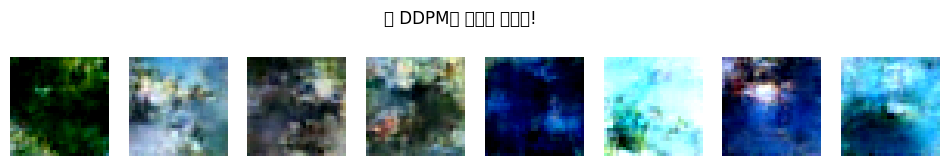

In [8]:
# ── 7. Sampling (TODO ③, Algorithm 2) ─────────────────────
@torch.no_grad()
def p_sample(model, x_t, t_val):
    t = torch.full((x_t.shape[0],), t_val, device=device, dtype=torch.long)
    beta_t      = extract(betas, t, x_t.shape)
    alpha_t     = extract(alphas, t, x_t.shape)
    sqrt_1mab_t = extract(sqrt_one_minus_alphas_bar, t, x_t.shape)

    eps_theta = model(x_t, t)                       # 노이즈 예측

    # ✏️ TODO ③-1: reverse 평균 mean 식을 완성하세요
    #   mean = (1/√α_t) · ( x_t − (1−α_t)/√(1−ᾱ_t) · eps_theta )
    mean = (1.0 / torch.sqrt(alpha_t)) * (x_t - (beta_t / sqrt_1mab_t) * eps_theta)

    if t_val == 0:
        return mean                                 # 마지막 step: 노이즈 X
    else:
        # ✏️ TODO ③-2: σ_t·z 추가 (σ_t = √β_t)
        noise = torch.randn_like(x_t)
        return mean + torch.sqrt(beta_t) * noise

@torch.no_grad()
def sample(model, n=8):
    model.eval()
    x = torch.randn(n, 3, 32, 32, device=device)    # x_T ~ N(0,I)
    for t_val in reversed(range(T)):                # T-1 → 0
        x = p_sample(model, x, t_val)
    return x

generated = sample(model, n=8)
show_images(generated, '🎉 DDPM이 생성한 이미지!')